# Tutorial 4: Aligning spatial transcriptomics data and spatial proteomics data of mouse thymus slices 

## Data Preparation

Please download the required data files from the provided link:
[Download here](https://pan.baidu.com/s/17K1cmxOPmhSvV6dG6gnafw?pwd=sjbx)

- `2_RNA.h5ad`
- `4_ADT.h5ad`

After downloading, place both files into the `datasets` folder located in the same directory as this notebook.

The folder structure should be organized as follows:

```
project_root/
│
├── datasets/
│   └── MT/
│       ├── 2_RNA.h5ad
│       └── 4_ADT.h5ad
│
├── Tutorial4_Aligning_spatial_transcriptomics_data_and_spatial_proteomics_data_of_mouse_thymus_slices.ipynb
│
└── SpaMOMA/
```

## import packages

In [1]:
import os
import scanpy as sc
from SpaMOMA.SpaMOMA import SpaMOMA

## Specify Slice Metadata

In [2]:
save_directory = "./SpaMOMA_output/MT/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="2_RNA",  
    raw_data_path="./datasets/MT/2_RNA.h5ad",  
    feature="rna"  
)
spamoma.add_slice(
    sample_id="4_ADT", 
    raw_data_path="./datasets/MT/4_ADT.h5ad", 
    feature="protein"  
)
spamoma.set_reference('2_RNA')
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['4_ADT'] to 2_RNA


## Data Preprocessing

preprocessing rna features...


------Calculating spatial graph...


The graph contains 29771 edges, 4253 cells.
7.0000 neighbors per cell on average.
Size of Input:  (4253, 3000)


2026-02-19 14:16:04.044179: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-19 14:16:04.052848: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [01:23<00:00,  5.97it/s]

preprocessing protein features...
------Calculating spatial graph...


The graph contains 29596 edges, 4228 cells.
7.0000 neighbors per cell on average.
Size of Input:  (4228, 19)


2026-02-19 14:17:29.771302: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



100%|██████████| 500/500 [00:36<00:00, 13.60it/s]

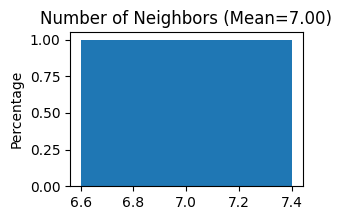

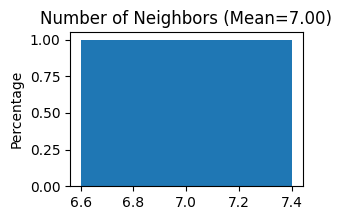

In [3]:
spamoma.preprocess_input_slices()

## Generate Spatial Pattern Images

generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


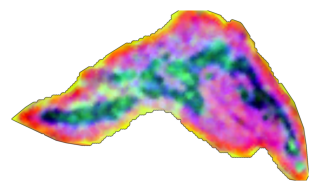

Img for 2_RNA is saved to ./SpaMOMA_output/MT/2_RNA/RGB.png
generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


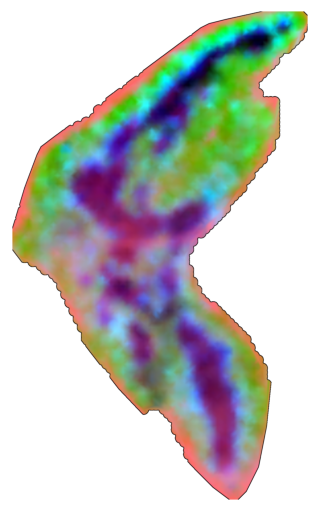

Img for 4_ADT is saved to ./SpaMOMA_output/MT/4_ADT/RGB.png


In [4]:
spamoma.generate_imgs()

In [5]:
spamoma.input_slice_dict

{'2_RNA': {'sample_id': '2_RNA',
  'raw_data_path': './datasets/MT/2_RNA.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 4253 × 3000
      obs: 'orig.ident', 'x', 'y', 'spot_x', 'spot_y', 'img_x', 'img_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      var: 'var_type', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns: 'hvg', 'log1p', 'spatial_neighbors', 'moranI'
      obsm: 'spatial', 'pca'
      obsp: 'spatial_connectivities', 'spatial_distances',
  'SPI_path': './SpaMOMA_output/MT/2_RNA/RGB.png'},
 '4_ADT': {'sample_id': '4_ADT',
  'raw_data_path': './datasets/MT/4_ADT.h5ad',
  'feature': 'protein',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 4228 × 19
      obs: 'orig.ident', 'x', 'y', 'spot_x', 'spot_y', 'img_x', 'img_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      var: 'protein_name', 'var_type'
      obsm: 'spatial', 'pca',
  'SPI_path': 

## Model Training

In [6]:
spamoma.train(coarse_epochs=1000,fine_epochs=300,parallel_mode=True,coarse_gpu=1,fine_gpu=1)

start coarse adaptation...
start fine adaptation...


fine adaptation done!
coarse adaptation done!


## Slice Alignment

In [7]:
spamoma.align_slices()

aligned 2_RNA adata is saved to: ./SpaMOMA_output/MT//alignment_output/2_RNA.h5ad
****************** aligning 4_ADT to 2_RNA ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/MT//coarse_model/adapted_model_epoch_1000.pth


current Roma instance ID: 128099959915808
preprocessing is already resized
Force resize to 560x560


coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/MT//fine_model/adapted_model_epoch_300.pth


current Roma instance ID: 128100920472864
preprocessing is already resized
Force resize to 560x560


aligned 4_ADT adata is saved to: ./SpaMOMA_output/MT//alignment_output/4_ADT.h5ad
fine alignment done!


## Visualize Alignment Results

Overlaying aligned slice for sample: 4_ADT


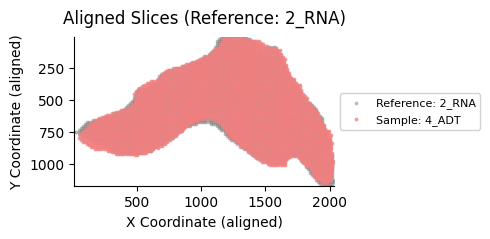

In [8]:
spamoma.visualize_aligned_slices(point_size=3,figsize=(5, 4))

## Omics-to-omics translation

In [9]:
adata1=spamoma.read_aligned_data('2_RNA')
adata2=spamoma.read_aligned_data('4_ADT')

### transfer omics from adata2 to adata1, and transfer omics from adata1 to adata2

In [ ]:
adata1_complemented=spamoma.SpaMOMA_translate(adata1,adata2,k_neighbors=4,overlap_distance_threshold=90,save_path='./SpaMOMA_output/MT/translation_output/2_RNA_complemented.h5ad')
adata2_complemented=spamoma.SpaMOMA_translate(adata2,adata1,k_neighbors=4,overlap_distance_threshold=90,save_path='./SpaMOMA_output/MT/translation_output/4_ADT_complemented.h5ad')

Translating omics-data from adata_src to adata_target...
Translating omics-data from adata_src to adata_target...


## Identify spatial domains for each translated slice

************ running SpatialGlue ***************
processing rna


processing protein



100%|██████████| 600/600 [00:59<00:00, 10.07it/s]

Model training finished!

************ running MISO ***************


CUDA is available. GPU: NVIDIA A100 80GB PCIe


...


  |======================================================================| 100%

fitting ...



  |======================================================================| 100%

got consensus_matrix


got consensus_labels


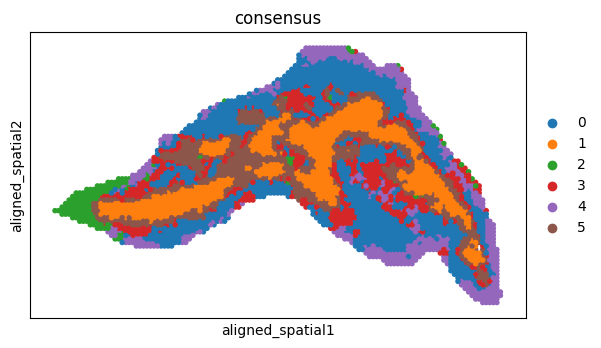

In [11]:
adata=spamoma.SpaMOMA_clustering(adata1,'rna',adata1_complemented,'protein',data_type='SPOTS',n_domains=6,
                                 method_list=['PRESENT','MISO','SpatialGlue'],cluster_types=['mclust'],add_key='consensus')
sc.pl.spatial(adata,color='consensus',basis='aligned_spatial',spot_size=25)

In [12]:
cluster_save_dir=f"{save_directory}/cluster_result_single_slice/"
if not os.path.exists(cluster_save_dir):
    os.makedirs(cluster_save_dir,exist_ok=True)
adata.write(f'{cluster_save_dir}/2_RNA.h5ad')

************ running SpatialGlue ***************
processing protein
processing rna



100%|██████████| 600/600 [00:57<00:00, 10.45it/s]

Model training finished!

************ running MISO ***************
CUDA is available. GPU: NVIDIA A100 80GB PCIe


Training network for modality 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training network for modality 2:   0%|          | 0/1000 [00:00<?, ?it/s]

...


  |======================================================================| 100%

fitting ...



  |======================================================================| 100%

got consensus_matrix


got consensus_labels


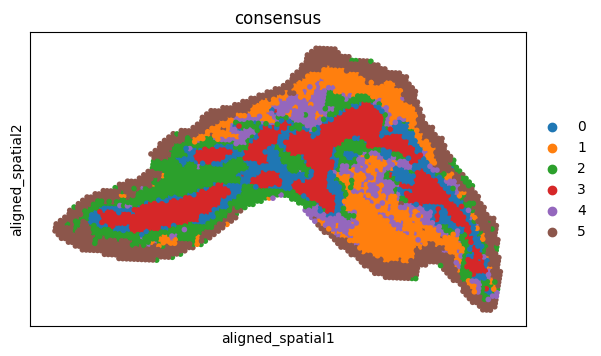

In [13]:
adata=spamoma.SpaMOMA_clustering(adata2,'protein',adata2_complemented,'rna',data_type='SPOTS',n_domains=6,
                                 method_list=['PRESENT','MISO','SpatialGlue'],cluster_types=['mclust'],add_key='consensus')
sc.pl.spatial(adata,color='consensus',basis='aligned_spatial',spot_size=25)

In [14]:
cluster_save_dir=f"{save_directory}/cluster_result_single_slice/"
if not os.path.exists(cluster_save_dir):
    os.makedirs(cluster_save_dir,exist_ok=True)
adata.write(f'{cluster_save_dir}/4_ADT.h5ad')

## Jointly identify spatial domains across the two translated slices

In [15]:
multiple_slices_dict={
    '2_RNA':{
        'rna':adata1.copy(),
        'protein':adata1_complemented.copy()
    },
    '4_ADT':{
        'rna':adata2_complemented.copy(),
        'protein':adata2.copy()
    }
}

reference_modality_dict={
    '2_RNA':'rna',
    '4_ADT':'protein'
}

In [ ]:
adata_dict=spamoma.SpaMOMA_clustering_multiple_slices(multiple_slices_dict,reference_modality_dict,batch_key='batch',n_domains=6)


Loading data and parameters...
Input data has been loaded


First-stage trains basic model:  34%|███▍      | 34/100 [02:09<04:11,  3.81s/it, NLL_loss=0.0642, BNN_loss=1.34, MSE_loss=0.385, IOA_loss=0.169, ES counter=20, ES patience=20] 


Early stop the first-stage training process


Second-stage trains BC model:  19%|█▉        | 19/100 [06:49<29:05, 21.55s/it, IBA_loss=0.891, IBP_loss=0.104, DISC_loss=0.699, GEN_loss=-0.698, ES counter=10, ES patience=10]


Early stop the second-stage training process
Succeed to find 6 clusters at resolution 0.094

========== Processing batch: 2_RNA ==========

========== Processing batch: 4_ADT ==========


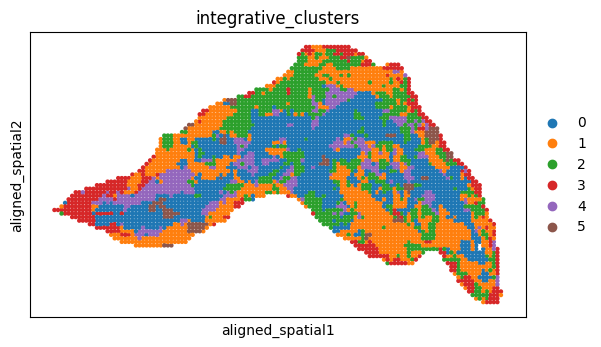

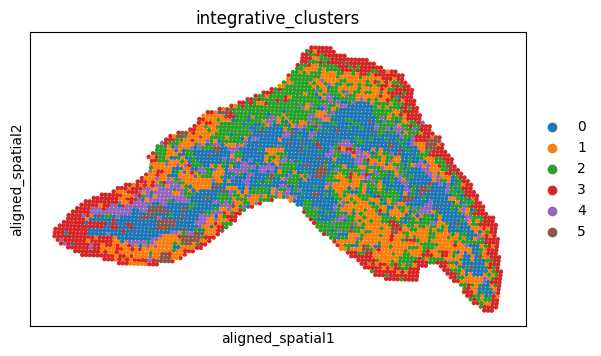

In [ ]:
sc.pl.spatial(adata_dict['2_RNA'],color='integrative_clusters',basis='aligned_spatial',spot_size=20)
sc.pl.spatial(adata_dict['4_ADT'],color='integrative_clusters',basis='aligned_spatial',spot_size=20)

In [ ]:
cluster_save_dir=f"{save_directory}/cluster_result_multiple_slices/"
if not os.path.exists(cluster_save_dir):
    os.makedirs(cluster_save_dir,exist_ok=True)
adata_dict['2_RNA'].write(f'{cluster_save_dir}/2_RNA.h5ad')
adata_dict['4_ADT'].write(f'{cluster_save_dir}/4_ADT.h5ad')